In [1]:
import itertools
import functools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import stim
import cirq

from encoded.repetition_code import repetition_H, repetition_CNOT
from encoded.tcc import get_stabilizer_generators, stabilizers_to_encoder

/Users/ryan/prof/work/encoded/envencoded/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# ============================================================
# Circuit-level depolarizing noise model:
#   After each 1Q gate/idle: DEPOLARIZE1(p)
#   After each 2Q gate:      DEPOLARIZE2(p)
# ============================================================

def build_physical_bell(p: float) -> stim.Circuit:
    """Physical 2-qubit Bell state: H(q0) -> CNOT(q0,q1)."""
    c = stim.Circuit()
    # Moment 1: H on q0, q1 idle
    c.append("H", [0])
    c.append("DEPOLARIZE1", [0, 1], p)
    c.append("TICK")
    # Moment 2: CNOT
    c.append("CX", [0, 1])
    c.append("DEPOLARIZE2", [0, 1], p)
    c.append("TICK")
    c.append("M", [0, 1])
    return c


def build_repetition_bell(n: int, p: float) -> stim.Circuit:
    """Encoded Bell state for repetition code distance n.

    Circuit: H_L(block1) -> CNOT_L(block1, block2)
    Simplified: since |0_L> = |0...0>, the backward CNOT chain of H_L is trivial.
    Effective circuit: H(q0) -> CX chain(0->1->...->n-1) -> transversal CX.
    """
    c = stim.Circuit()
    all_q = list(range(2 * n))

    # Moment 1: H on q0, all others idle
    c.append("H", [0])
    c.append("DEPOLARIZE1", [0], p)
    idle = list(range(1, 2 * n))
    c.append("DEPOLARIZE1", idle, p)
    c.append("TICK")

    # Moments 2..n: CNOT chain creating GHZ-like state on block 1
    for step in range(n - 1):
        c.append("CX", [step, step + 1])
        idle = sorted(set(all_q) - {step, step + 1})
        c.append("DEPOLARIZE2", [step, step + 1], p)
        if idle:
            c.append("DEPOLARIZE1", idle, p)
        c.append("TICK")

    # Final moment: transversal CNOT (all in parallel, no idle qubits)
    for i in range(n):
        c.append("CX", [i, n + i])
    for i in range(n):
        c.append("DEPOLARIZE2", [i, n + i], p)
    c.append("TICK")

    c.append("M", all_q)
    return c


def build_color_code_bell(d: int, p: float):
    """Encoded Bell state for triangular color code distance d.

    Circuit: encode(block1) -> encode(block2) -> H_L(block1) -> CNOT_L(block1, block2)
    Encoding from stim tableau. Logical gates are transversal.

    Returns: (stim_circuit, n_qubits_per_block, stabilizer_strings)
    """
    stabs_all = get_stabilizer_generators(d)
    n = len(stabs_all[0])  # qubits per block
    enc = stabilizers_to_encoder([stim.PauliString(s) for s in stabs_all[::-1]])
    all_q = list(range(2 * n))

    c = stim.Circuit()

    # Encode both blocks
    for offset in [0, n]:
        for inst in enc.flattened():
            name = inst.name
            if name == "TICK":
                continue
            tgts = [t.value + offset for t in inst.targets_copy()]
            c.append(name, tgts, inst.gate_args_copy())
        # One noise layer per encoding block
        c.append("DEPOLARIZE1", all_q, p)
        c.append("TICK")

    # Logical H on block 1 (transversal)
    c.append("H", list(range(n)))
    c.append("DEPOLARIZE1", all_q, p)
    c.append("TICK")

    # Transversal CNOT
    for i in range(n):
        c.append("CX", [i, n + i])
    for i in range(n):
        c.append("DEPOLARIZE2", [i, n + i], p)
    c.append("TICK")

    c.append("M", all_q)
    return c, n, stabs_all

In [3]:
# ============================================================
# Evaluation functions: compute <Z_L Z_L> via post-selection
# ============================================================

def eval_physical(samples: np.ndarray) -> float:
    """Compute <ZZ> for physical Bell state from measurement samples."""
    nshots = len(samples)
    same = np.sum(samples[:, 0] == samples[:, 1])
    return (2 * same - nshots) / nshots


def eval_repetition(samples: np.ndarray, n: int):
    """Compute post-selected <Z_L1 Z_L2> for repetition code.

    Post-selection: all qubits in each block must have the same value
    (Z_i Z_{i+1} stabilizer syndromes all +1).
    Observable: Z_0 Z_n (logical Z on first qubit of each block).
    """
    nshots = len(samples)
    valid = np.ones(nshots, dtype=bool)
    for i in range(n - 1):
        valid &= samples[:, i] == samples[:, i + 1]
        valid &= samples[:, n + i] == samples[:, n + i + 1]
    if valid.sum() < 50:
        return None
    vs = samples[valid]
    return float(np.mean((-1.0) ** (vs[:, 0].astype(int) + vs[:, n].astype(int))))


def eval_color_code(samples: np.ndarray, n: int, stabs: list):
    """Compute post-selected <Z_L1 Z_L2> for color code.

    Post-selection on Z-type stabilizer syndromes for both blocks.
    Observable: Z^{otimes 2n} (logical Z = Z^{otimes n} for each block).

    Note: Z-stabilizer post-selection is sufficient for the Z_L Z_L observable
    because Z errors commute with Z_L and don't affect the expectation value.
    """
    z_stabs = [s for s in stabs if "Z" in s and "X" not in s]
    valid = np.ones(len(samples), dtype=bool)
    for s in z_stabs:
        support = [i for i, ch in enumerate(s) if ch == "Z"]
        for offset in [0, n]:
            shifted = [idx + offset for idx in support]
            parity = np.sum(samples[:, shifted], axis=1) % 2
            valid &= parity == 0
    if valid.sum() < 50:
        return None
    vs = samples[valid]
    return float(np.mean((-1.0) ** (np.sum(vs, axis=1) % 2)))

## Repetition code Bell state preparation and measure $\langle \bar{Z} \bar{Z} \rangle$

In [4]:
nshots = 500_000
rep_distances = [3, 5, 7, 9, 11]

p_values = np.concatenate([
    np.arange(0.005, 0.05, 0.005),
    np.arange(0.05, 0.25, 0.01),
])

# Physical baseline
phys_evs = {}
for p in p_values:
    c = build_physical_bell(p)
    samples = c.compile_sampler().sample(nshots)
    phys_evs[p] = eval_physical(samples)

# Repetition code
rep_evs = {}
for n in rep_distances:
    rep_evs[n] = {}
    for p in p_values:
        c = build_repetition_bell(n, p)
        samples = c.compile_sampler().sample(nshots)
        rep_evs[n][p] = eval_repetition(samples, n)
    print(f"  Repetition n={n} done")

  Repetition n=3 done
  Repetition n=5 done
  Repetition n=7 done
  Repetition n=9 done
  Repetition n=11 done


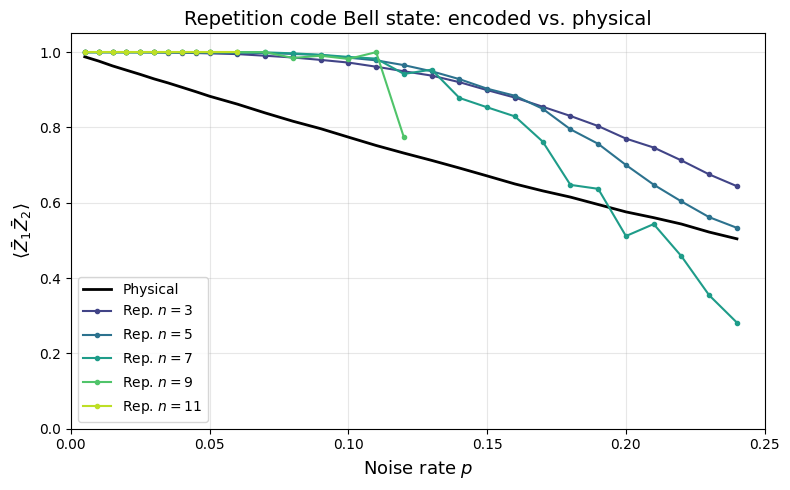

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_values, [phys_evs[p] for p in p_values], "k-", linewidth=2, label="Physical")

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(rep_distances)))
for idx, n in enumerate(rep_distances):
    vals = [rep_evs[n][p] for p in p_values]
    p_valid = [p for p, v in zip(p_values, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax.plot(p_valid, v_valid, "o-", color=colors[idx], markersize=3, label=f"Rep. $n={n}$")

ax.set_xlabel("Noise rate $p$", fontsize=13)
ax.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax.set_title("Repetition code Bell state: encoded vs. physical", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("paper/rep_bell_zz_vs_noise.png", dpi=200, bbox_inches="tight")
plt.show()

## Triangular color code Bell state preparation and measure $\langle \bar{Z} \bar{Z} \rangle$ or $\langle \bar{X} \bar{X} \rangle$

In [ ]:
nshots: int = 200_000_000

cc_distances = [3, 5, 7]

cc_evs = {}
for d in cc_distances:
    cc_evs[d] = {}
    for p in p_values:
        circ, n, stabs = build_color_code_bell(d, p)
        print(f"{n=}")
        samples = circ.compile_sampler().sample(nshots)
        cc_evs[d][p] = eval_color_code(samples, n, stabs)
    print(f"  Color code d={d} done")

n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
n=7
  Color code d=3 done
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
n=19
  Color code d=5 done
n=37
n=37


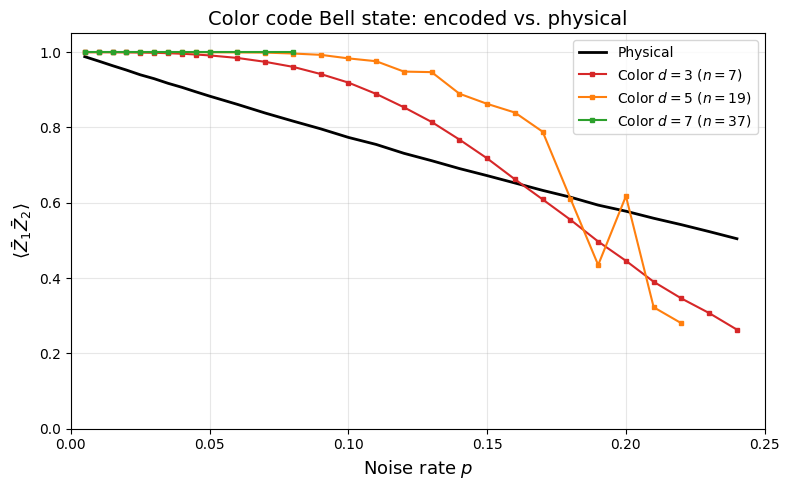

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_values, [phys_evs[p] for p in p_values], "k-", linewidth=2, label="Physical")

cc_colors = ["tab:red", "tab:orange", "tab:green"]
for idx, d in enumerate(cc_distances):
    n_q = len(get_stabilizer_generators(d)[0])
    vals = [cc_evs[d][p] for p in p_values]
    p_valid = [p for p, v in zip(p_values, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax.plot(p_valid, v_valid, "s-", color=cc_colors[idx], markersize=3, label=f"Color $d={d}$ ($n={n_q}$)")

ax.set_xlabel("Noise rate $p$", fontsize=13)
ax.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax.set_title("Color code Bell state: encoded vs. physical", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("paper/cc_bell_zz_vs_noise.png", dpi=200, bbox_inches="tight")
plt.show()

## Pseudo-threshold plot

Find the pseudo-threshold $p^*$ for each code: the noise rate at which the encoded $\langle \bar{Z}_1 \bar{Z}_2 \rangle$ crosses below the physical $\langle Z_1 Z_2 \rangle$.

**Note on the repetition code:** For the $\bar{Z}\bar{Z}$ observable under depolarizing noise, the repetition code has no pseudo-threshold ($p^* \to p_{\max}$). This is because:
1. $Z$ errors commute with $\bar{Z}$ and don't affect the observable.
2. Only $X$-type errors (1/3 of depolarizing) are relevant, and the code catches all weight $< n$ patterns via post-selection.
3. A logical $X$ error requires $X^{\otimes n}$ which is exponentially suppressed.

In [8]:
def find_pseudothreshold(p_arr, phys_arr, enc_dict):
    """Find pseudo-threshold by interpolation of the crossing point."""
    thresholds = {}
    for key, evs in enc_dict.items():
        vals = np.array([evs.get(p) for p in p_arr])
        phys = np.array([phys_arr[p] for p in p_arr])

        crossing = None
        for i in range(len(p_arr) - 1):
            e1, e2 = vals[i], vals[i + 1]
            p1, p2 = phys[i], phys[i + 1]
            if e1 is not None and e2 is not None:
                d1 = e1 - p1
                d2 = e2 - p2
                if d1 > 0 and d2 <= 0:
                    crossing = p_arr[i] + (p_arr[i + 1] - p_arr[i]) * d1 / (d1 - d2)
                    break
        thresholds[key] = crossing
    return thresholds


rep_thresholds = find_pseudothreshold(p_values, phys_evs, rep_evs)
cc_thresholds = find_pseudothreshold(p_values, phys_evs, cc_evs)

print("Repetition code pseudo-thresholds:")
for n, pt in rep_thresholds.items():
    print(f"  n={n}: {'p* = %.4f' % pt if pt else 'no crossing (encoded always wins)'}")

print("\nColor code pseudo-thresholds:")
for d, pt in cc_thresholds.items():
    n_q = len(get_stabilizer_generators(d)[0])
    print(f"  d={d} (n={n_q}): {'p* = %.4f' % pt if pt else 'no crossing / insufficient data'}")

Repetition code pseudo-thresholds:
  n=3: no crossing (encoded always wins)
  n=5: p* = 0.2369
  n=7: p* = 0.1950
  n=9: no crossing (encoded always wins)
  n=11: no crossing (encoded always wins)

Color code pseudo-thresholds:
  d=3 (n=7): p* = 0.1625
  d=5 (n=19): no crossing / insufficient data


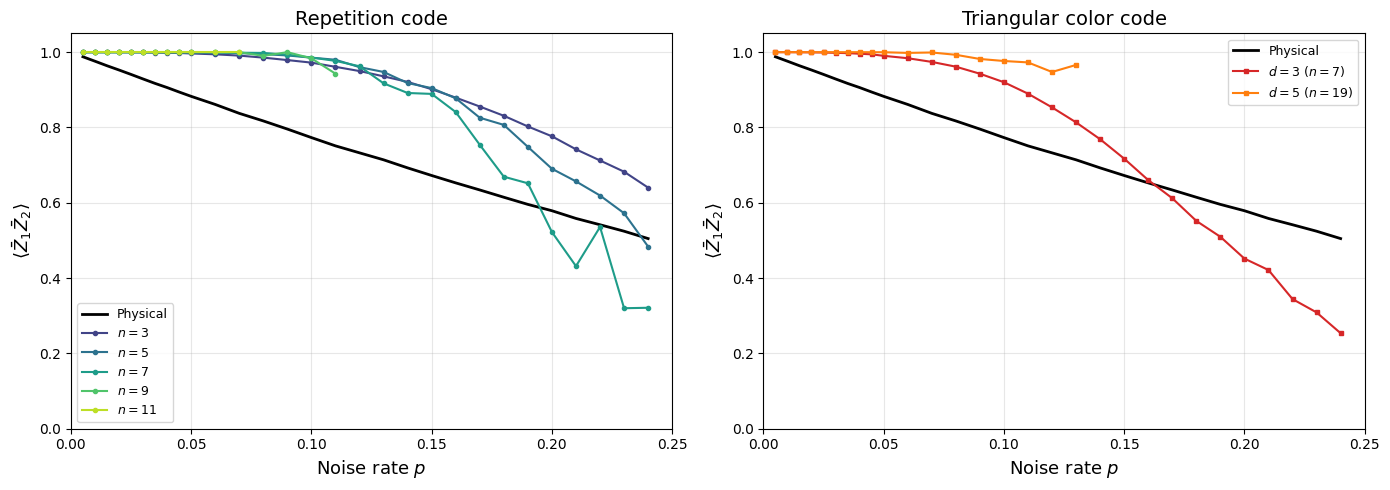

In [9]:
# Combined plot: encoded vs physical for all codes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Repetition code
ax1.plot(p_values, [phys_evs[p] for p in p_values], "k-", linewidth=2, label="Physical")
colors_rep = plt.cm.viridis(np.linspace(0.2, 0.9, len(rep_distances)))
for idx, n in enumerate(rep_distances):
    vals = [rep_evs[n][p] for p in p_values]
    p_valid = [p for p, v in zip(p_values, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax1.plot(p_valid, v_valid, "o-", color=colors_rep[idx], markersize=3, label=f"$n={n}$")
ax1.set_xlabel("Noise rate $p$", fontsize=13)
ax1.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax1.set_title("Repetition code", fontsize=14)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 0.25)
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)

# Right: Color code
ax2.plot(p_values, [phys_evs[p] for p in p_values], "k-", linewidth=2, label="Physical")
cc_colors = ["tab:red", "tab:orange"]
for idx, d in enumerate(cc_distances):
    n_q = len(get_stabilizer_generators(d)[0])
    vals = [cc_evs[d][p] for p in p_values]
    p_valid = [p for p, v in zip(p_values, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax2.plot(p_valid, v_valid, "s-", color=cc_colors[idx], markersize=3, label=f"$d={d}$ ($n={n_q}$)")
ax2.set_xlabel("Noise rate $p$", fontsize=13)
ax2.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax2.set_title("Triangular color code", fontsize=14)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 0.25)
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("paper/pseudothreshold_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Noise model 2: Scaled `GenericBackendV2` (FakeBackend)

Use `qiskit.providers.fake_provider.GenericBackendV2`, then scale all error rates by a multiplicative factor. This gives a single tunable parameter while preserving the relative structure of real hardware noise (e.g., 2Q gates are ~10x noisier than 1Q gates, readout errors are distinct from gate errors).

In [10]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, QuantumError, ReadoutError
from qiskit.providers.fake_provider import GenericBackendV2


def scaled_noise_model_from_backend(backend, scale: float) -> NoiseModel:
    """Extract noise model from a Qiskit backend and scale all error rates.

    Args:
        backend: A Qiskit backend (e.g., GenericBackendV2).
        scale: Multiplicative factor for all error probabilities.
               scale=1 gives the original noise; scale=10 is 10x noisier.
    """
    base = NoiseModel.from_backend(backend)
    scaled = NoiseModel()
    scaled._basis_gates = base._basis_gates

    # Scale gate errors
    for gate_name, qerr_dict in base._local_quantum_errors.items():
        for qubits, err in qerr_dict.items():
            probs = np.array(err.probabilities)
            p_err = 1 - probs[0]
            p_err_scaled = min(p_err * scale, 0.99)
            new_probs = probs.copy()
            if p_err > 0:
                new_probs[0] = 1 - p_err_scaled
                new_probs[1:] = probs[1:] * (p_err_scaled / p_err)
            scaled.add_quantum_error(
                QuantumError(list(zip(err.circuits, new_probs))),
                gate_name, list(qubits),
            )

    # Scale readout errors
    for qubits, rerr in base._local_readout_errors.items():
        probs = rerr.probabilities
        new_probs = []
        for row in probs:
            ci = np.argmax(row)
            pw = 1 - row[ci]
            pws = min(pw * scale, 0.49)
            nr = row.copy()
            if pw > 0:
                nr[ci] = 1 - pws
                for i in range(len(nr)):
                    if i != ci:
                        nr[i] = row[i] * (pws / pw)
            new_probs.append(nr)
        scaled.add_readout_error(ReadoutError(new_probs), list(qubits))

    return scaled


def build_qiskit_physical_bell(nq: int) -> QuantumCircuit:
    """Physical Bell circuit on qubits 0,1 of an nq-qubit register."""
    qc = QuantumCircuit(nq, nq)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc


def build_qiskit_repetition_bell(n: int) -> QuantumCircuit:
    """Encoded Bell circuit for repetition code distance n."""
    nq = 2 * n
    qc = QuantumCircuit(nq, nq)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    for i in range(n):
        qc.cx(i, n + i)
    qc.measure(list(range(nq)), list(range(nq)))
    return qc


def build_qiskit_color_code_bell(d: int) -> QuantumCircuit:
    """Encoded Bell circuit for color code distance d.

    Uses stimcirq to get the encoding circuit, then converts to Qiskit.
    Returns: (QuantumCircuit, n_qubits_per_block, stabilizer_strings)
    """
    stabs_all = get_stabilizer_generators(d)
    n = len(stabs_all[0])
    enc = stabilizers_to_encoder([stim.PauliString(s) for s in stabs_all[::-1]])
    nq = 2 * n
    qc = QuantumCircuit(nq, nq)

    # Encoding for both blocks
    for offset in [0, n]:
        for inst in enc.flattened():
            name = inst.name
            if name == "TICK":
                continue
            tgts = [t.value + offset for t in inst.targets_copy()]
            args = inst.gate_args_copy()
            if name == "H":
                for t in tgts:
                    qc.h(t)
            elif name == "CZ":
                qc.cz(tgts[0], tgts[1])
            elif name == "CX" or name == "CNOT":
                qc.cx(tgts[0], tgts[1])
            elif name == "S":
                for t in tgts:
                    qc.s(t)
            elif name == "S_DAG":
                for t in tgts:
                    qc.sdg(t)
            elif name == "RX":
                for t in tgts:
                    qc.h(t)  # RX in stim = X-basis reset = H|0> = |+>

    # Logical H on block 1
    for i in range(n):
        qc.h(i)
    # Transversal CNOT
    for i in range(n):
        qc.cx(i, n + i)
    qc.measure(list(range(nq)), list(range(nq)))
    return qc, n, stabs_all


def eval_qiskit_counts(counts: dict, n_total: int) -> float:
    """Compute <ZZ> or <Z_L Z_L> from Qiskit counts dict (physical, 2-qubit)."""
    total = 0
    same = 0
    for bitstr, count in counts.items():
        bits = bitstr[::-1]  # Qiskit is little-endian
        total += count
        if bits[0] == bits[1]:
            same += count
    return (2 * same - total) / total


def eval_qiskit_repetition(counts: dict, n: int):
    """Post-selected <Z_L1 Z_L2> from Qiskit counts for repetition code."""
    valid_total = 0
    zz_sum = 0
    for bitstr, count in counts.items():
        bits = bitstr[::-1]  # little-endian
        block1 = [int(bits[i]) for i in range(n)]
        block2 = [int(bits[n + i]) for i in range(n)]
        # Post-selection: all qubits in each block agree
        if len(set(block1)) == 1 and len(set(block2)) == 1:
            valid_total += count
            zz = (-1) ** (block1[0] + block2[0])
            zz_sum += zz * count
    if valid_total < 50:
        return None
    return zz_sum / valid_total


def eval_qiskit_color_code(counts: dict, n: int, stabs: list):
    """Post-selected <Z_L1 Z_L2> from Qiskit counts for color code."""
    z_stabs = [s for s in stabs if "Z" in s and "X" not in s]
    valid_total = 0
    zz_sum = 0
    for bitstr, count in counts.items():
        bits = [int(b) for b in bitstr[::-1]]  # little-endian
        # Check Z-stabilizer syndromes for both blocks
        ok = True
        for s in z_stabs:
            support = [i for i, ch in enumerate(s) if ch == "Z"]
            for offset in [0, n]:
                parity = sum(bits[idx + offset] for idx in support) % 2
                if parity != 0:
                    ok = False
                    break
            if not ok:
                break
        if ok:
            valid_total += count
            total_parity = sum(bits) % 2
            zz_sum += ((-1) ** total_parity) * count
    if valid_total < 50:
        return None
    return zz_sum / valid_total

In [11]:
# Sweep over noise scale factors
# scale=1 corresponds to base GenericBackendV2 noise (~1% CX error)
nshots_fb = 200_000
rep_distances_fb = [3, 5, 7]
cc_distances_fb = [3]  # d=5 (38 qubits) exceeds AerSimulator memory
scales = np.array([1, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80])

# Physical baseline (2-qubit backend)
fb_phys = {}
backend_phys = GenericBackendV2(num_qubits=2, seed=42)
for sc in scales:
    nm = scaled_noise_model_from_backend(backend_phys, sc)
    sim = AerSimulator(noise_model=nm)
    qc = build_qiskit_physical_bell(2)
    result = sim.run(transpile(qc, basis_gates=nm.basis_gates), shots=nshots_fb).result()
    fb_phys[sc] = eval_qiskit_counts(result.get_counts(), 2)
    print(f"  Physical scale={sc}: <ZZ>={fb_phys[sc]:.4f}")

# Repetition code
fb_rep = {}
for n in rep_distances_fb:
    fb_rep[n] = {}
    nq = 2 * n
    backend = GenericBackendV2(num_qubits=nq, seed=42)
    for sc in scales:
        nm = scaled_noise_model_from_backend(backend, sc)
        sim = AerSimulator(noise_model=nm)
        qc = build_qiskit_repetition_bell(n)
        result = sim.run(transpile(qc, basis_gates=nm.basis_gates), shots=nshots_fb).result()
        fb_rep[n][sc] = eval_qiskit_repetition(result.get_counts(), n)
    vals = [f"{fb_rep[n][s]:.4f}" if fb_rep[n][s] is not None else "None" for s in [1, 50]]
    print(f"  Rep n={n} done: scale=1 -> {vals[0]}, scale=50 -> {vals[1]}")

# Color code
fb_cc = {}
for d in cc_distances_fb:
    fb_cc[d] = {}
    stabs_all_d = get_stabilizer_generators(d)
    n = len(stabs_all_d[0])
    nq = 2 * n
    backend = GenericBackendV2(num_qubits=nq, seed=42)
    for sc in scales:
        nm = scaled_noise_model_from_backend(backend, sc)
        sim = AerSimulator(noise_model=nm)
        qc, _, stabs = build_qiskit_color_code_bell(d)
        result = sim.run(transpile(qc, basis_gates=nm.basis_gates), shots=nshots_fb).result()
        fb_cc[d][sc] = eval_qiskit_color_code(result.get_counts(), n, stabs)
    vals = [f"{fb_cc[d][s]:.4f}" if fb_cc[d][s] is not None else "None" for s in [1, 50]]
    print(f"  CC d={d} done: scale=1 -> {vals[0]}, scale=50 -> {vals[1]}")

  Physical scale=1: <ZZ>=0.9803


  Physical scale=5: <ZZ>=0.9102


  Physical scale=10: <ZZ>=0.8208


  Physical scale=15: <ZZ>=0.7373


  Physical scale=20: <ZZ>=0.6643


...

  Physical scale=80: <ZZ>=0.0932


  Rep n=3 done: scale=1 -> 1.0000, scale=50 -> 0.9501


  Rep n=5 done: scale=1 -> 1.0000, scale=50 -> 0.9992


  Rep n=7 done: scale=1 -> 1.0000, scale=50 -> 1.0000


  CC d=3 done: scale=1 -> 0.9787, scale=50 -> 0.1224


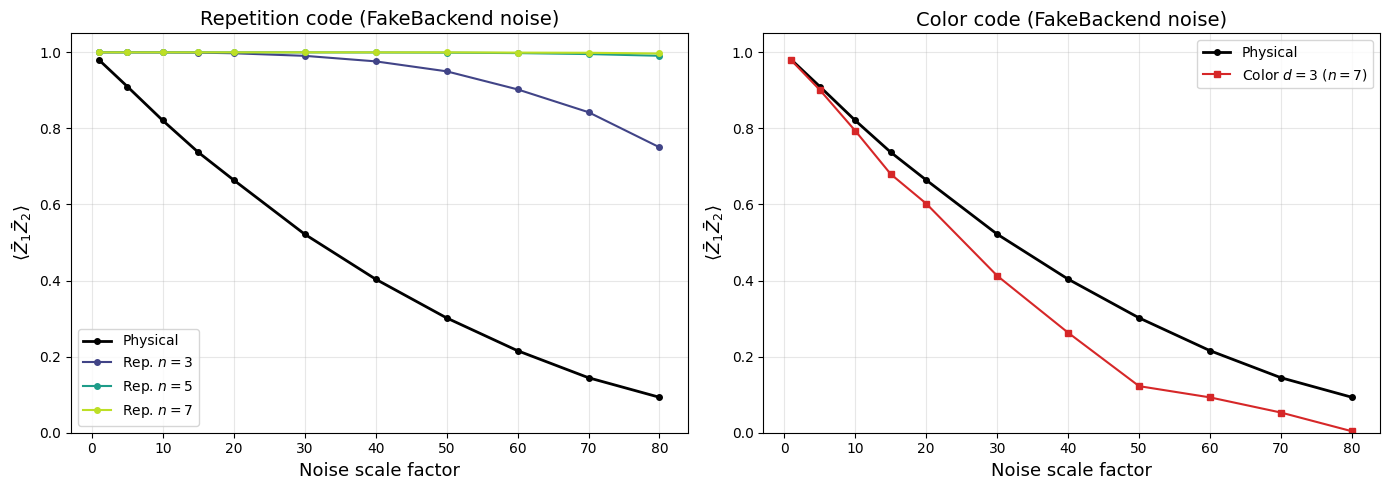

In [12]:
# Plot FakeBackend results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Repetition code
ax1.plot(scales, [fb_phys[s] for s in scales], "k-o", linewidth=2, markersize=4, label="Physical")
colors_rep = plt.cm.viridis(np.linspace(0.2, 0.9, len(rep_distances_fb)))
for idx, n in enumerate(rep_distances_fb):
    vals = [fb_rep[n][s] for s in scales]
    s_valid = [s for s, v in zip(scales, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax1.plot(s_valid, v_valid, "o-", color=colors_rep[idx], markersize=4, label=f"Rep. $n={n}$")
ax1.set_xlabel("Noise scale factor", fontsize=13)
ax1.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax1.set_title("Repetition code (FakeBackend noise)", fontsize=14)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)

# Right: Color code
ax2.plot(scales, [fb_phys[s] for s in scales], "k-o", linewidth=2, markersize=4, label="Physical")
cc_colors = ["tab:red", "tab:orange"]
for idx, d in enumerate(cc_distances_fb):
    n_q = len(get_stabilizer_generators(d)[0])
    vals = [fb_cc[d][s] for s in scales]
    s_valid = [s for s, v in zip(scales, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax2.plot(s_valid, v_valid, "s-", color=cc_colors[idx], markersize=4, label=f"Color $d={d}$ ($n={n_q}$)")
ax2.set_xlabel("Noise scale factor", fontsize=13)
ax2.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax2.set_title("Color code (FakeBackend noise)", fontsize=14)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("paper/fakebackend_bell_zz.png", dpi=200, bbox_inches="tight")
plt.show()

## Noise model 3: Bit-flip noise (validation against paper's analytical predictions)

Circuit-level bit-flip noise: $\mathcal{E}_i(p) = (1-p)I + pX_i$ after each 1Q gate/idle, and $\mathcal{E}_{i,j}(p) = (1-2p-p^2)I + p(X_i + X_j) + p^2 X_i X_j$ after each 2Q gate. This matches the noise model used in the paper's Section D for analytical noise propagation.

In [13]:
# ============================================================
# Bit-flip noise model:
#   After each 1Q gate/idle: X_ERRROR(p)
#   After each 2Q gate:      custom 2Q bit-flip channel
#
# stim's X_ERROR(p) applies X with probability p.
# For 2Q gates, the paper uses:
#   (1-2p-p^2)II + p(XI + IX) + p^2 XX
# We approximate this with independent X_ERROR(p) on each qubit,
# which gives (1-p)^2 II + p(1-p)(XI+IX) + p^2 XX — close for small p.
# ============================================================

def build_physical_bell_bf(p: float) -> stim.Circuit:
    """Physical Bell state with bit-flip noise."""
    c = stim.Circuit()
    c.append("H", [0])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")
    c.append("CX", [0, 1])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")
    c.append("M", [0, 1])
    return c


def build_repetition_bell_bf(n: int, p: float) -> stim.Circuit:
    """Encoded Bell state for repetition code with bit-flip noise."""
    c = stim.Circuit()
    all_q = list(range(2 * n))

    c.append("H", [0])
    c.append("X_ERROR", all_q, p)
    c.append("TICK")

    for step in range(n - 1):
        c.append("CX", [step, step + 1])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    for i in range(n):
        c.append("CX", [i, n + i])
    c.append("X_ERROR", all_q, p)
    c.append("TICK")

    c.append("M", all_q)
    return c


def build_color_code_bell_bf(d: int, p: float):
    """Encoded Bell state for color code with bit-flip noise."""
    stabs_all = get_stabilizer_generators(d)
    n = len(stabs_all[0])
    enc = stabilizers_to_encoder([stim.PauliString(s) for s in stabs_all[::-1]])
    all_q = list(range(2 * n))

    c = stim.Circuit()

    for offset in [0, n]:
        for inst in enc.flattened():
            name = inst.name
            if name == "TICK":
                continue
            tgts = [t.value + offset for t in inst.targets_copy()]
            c.append(name, tgts, inst.gate_args_copy())
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    c.append("H", list(range(n)))
    c.append("X_ERROR", all_q, p)
    c.append("TICK")

    for i in range(n):
        c.append("CX", [i, n + i])
    c.append("X_ERROR", all_q, p)
    c.append("TICK")

    c.append("M", all_q)
    return c, n, stabs_all

In [14]:
# ============================================================
# Exact analytical computation of <Z_L1 Z_L2> under bit-flip noise
# by propagating the X-error probability distribution through the circuit.
#
# For each moment: apply gate (permutes error patterns), then X_ERROR(p).
# At the end, project onto code space (both blocks all-0 or all-1 X-error)
# and compute the expectation value.
# ============================================================

def exact_zz_bitflip(n: int, p: float) -> float:
    """Compute exact <Z_L1 Z_L2> for repetition code Bell state under bit-flip noise.

    Tracks the full 2^{2n} probability distribution over X-error patterns.
    Feasible for n <= 7 (2^14 = 16384 states).
    """
    nq = 2 * n
    N = 1 << nq

    # Initialize: no errors
    prob = np.zeros(N)
    prob[0] = 1.0

    indices = np.arange(N)

    def apply_x_error_all(prob, p):
        """Apply independent X_ERROR(p) on all qubits."""
        for q in range(nq):
            mask = 1 << q
            partners = indices ^ mask
            prob = (1 - p) * prob + p * prob[partners]
        return prob

    def apply_cx(prob, control, target):
        """Apply CNOT: X on control propagates to target."""
        c_mask = 1 << control
        t_mask = 1 << target
        has_ctrl = (indices & c_mask) != 0
        new_idx = np.where(has_ctrl, indices ^ t_mask, indices)
        new_prob = np.zeros(N)
        np.add.at(new_prob, new_idx, prob)
        return new_prob

    # Moment 1: H(q0) [X->Z, irrelevant for tracking], then X_ERROR(p) on all
    prob = apply_x_error_all(prob, p)

    # Moments 2..n: CX chain on block 1, then X_ERROR(p)
    for step in range(n - 1):
        prob = apply_cx(prob, step, step + 1)
        prob = apply_x_error_all(prob, p)

    # Final moment: transversal CX, then X_ERROR(p)
    for i in range(n):
        prob = apply_cx(prob, i, n + i)
    prob = apply_x_error_all(prob, p)

    # Post-selection: keep patterns where each block is all-0 or all-1
    b1_mask = (1 << n) - 1
    b2_mask = b1_mask << n
    b1_all1 = b1_mask
    b2_all1 = b2_mask

    p_II = prob[0]                           # both blocks no error
    p_XI = prob[b1_all1]                     # X_L on block 1 only
    p_IX = prob[b2_all1]                     # X_L on block 2 only
    p_XX = prob[b1_all1 | b2_all1]           # X_L on both blocks

    denom = p_II + p_XI + p_IX + p_XX
    if denom < 1e-30:
        return None
    return (p_II - p_XI - p_IX + p_XX) / denom

In [15]:
# Bit-flip noise sweep — use wider range since pseudo-threshold is ~0.15
nshots_bf = 500_000
rep_distances_bf = [3, 5, 7, 9, 11]
cc_distances_bf = [3, 5]

p_values_bf = np.concatenate([
    np.arange(0.005, 0.05, 0.005),
    np.arange(0.05, 0.40, 0.01),
])

# Physical baseline
bf_phys = {}
for p in p_values_bf:
    c = build_physical_bell_bf(p)
    samples = c.compile_sampler().sample(nshots_bf)
    bf_phys[p] = eval_physical(samples)

# Repetition code
bf_rep = {}
for n in rep_distances_bf:
    bf_rep[n] = {}
    for p in p_values_bf:
        c = build_repetition_bell_bf(n, p)
        samples = c.compile_sampler().sample(nshots_bf)
        bf_rep[n][p] = eval_repetition(samples, n)
    print(f"  Repetition n={n} done")

# Color code
bf_cc = {}
for d in cc_distances_bf:
    bf_cc[d] = {}
    for p in p_values_bf:
        circ, n, stabs = build_color_code_bell_bf(d, p)
        samples = circ.compile_sampler().sample(nshots_bf)
        bf_cc[d][p] = eval_color_code(samples, n, stabs)
    print(f"  Color code d={d} done")

  Repetition n=3 done


  Repetition n=5 done


  Repetition n=7 done


  Repetition n=9 done


  Repetition n=11 done


  Color code d=3 done


  Color code d=5 done


  Analytical n=3 done
  Analytical n=5 done


  Analytical n=7 done
  Analytical physical done


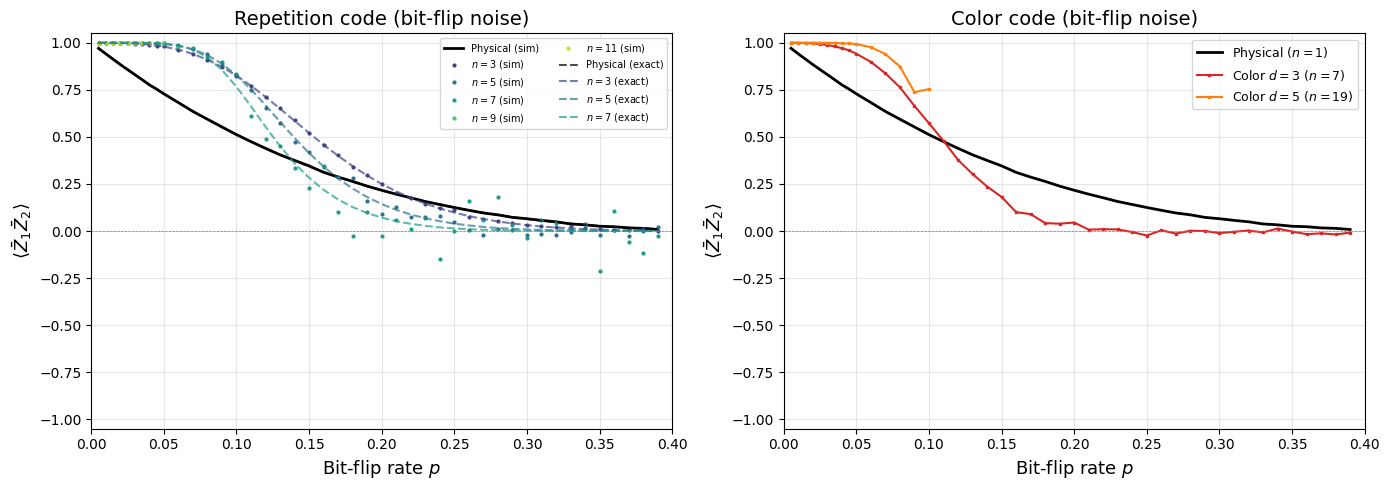

Bit-flip noise pseudo-thresholds:

Repetition code:
  n=3: p* = 0.2168
  n=5: p* = 0.1821
  n=7: p* = 0.1352
  n=9: no crossing in range
  n=11: no crossing in range

Color code:
  d=3 (n=7): p* = 0.1106
  d=5 (n=19): no crossing in range


In [16]:
# Compute analytical curves for repetition code (n <= 7)
analytical_ns = [n for n in rep_distances_bf if n <= 7]
analytical_rep = {}
for n in analytical_ns:
    analytical_rep[n] = {}
    for pv in p_values_bf:
        analytical_rep[n][pv] = exact_zz_bitflip(n, pv)
    print(f"  Analytical n={n} done")

analytical_phys = {}
for pv in p_values_bf:
    analytical_phys[pv] = exact_zz_bitflip(1, pv)
print("  Analytical physical done")

# Plot bit-flip results with analytical overlay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Repetition code
# Simulation curves (markers)
ax1.plot(p_values_bf, [bf_phys[p] for p in p_values_bf], "k-", linewidth=2, label="Physical (sim)")
colors_rep = plt.cm.viridis(np.linspace(0.2, 0.9, len(rep_distances_bf)))
for idx, n in enumerate(rep_distances_bf):
    vals = [bf_rep[n][p] for p in p_values_bf]
    p_valid = [p for p, v in zip(p_values_bf, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax1.plot(p_valid, v_valid, "o", color=colors_rep[idx], markersize=2, label=f"$n={n}$ (sim)")

# Analytical curves (dashed)
ax1.plot(p_values_bf, [analytical_phys[p] for p in p_values_bf], "k--", linewidth=1.5, alpha=0.7, label="Physical (exact)")
for idx, n in enumerate(analytical_ns):
    cidx = rep_distances_bf.index(n)
    vals = [analytical_rep[n][p] for p in p_values_bf]
    ax1.plot(p_values_bf, vals, "--", color=colors_rep[cidx], linewidth=1.5, alpha=0.7, label=f"$n={n}$ (exact)")

ax1.set_xlabel("Bit-flip rate $p$", fontsize=13)
ax1.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax1.set_title("Repetition code (bit-flip noise)", fontsize=14)
ax1.legend(fontsize=7, ncol=2)
ax1.set_xlim(0, 0.40)
ax1.set_ylim(-1.05, 1.05)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.grid(alpha=0.3)

# Right: Color code
ax2.plot(p_values_bf, [bf_phys[p] for p in p_values_bf], "k-", linewidth=2, label="Physical ($n=1$)")
cc_colors = ["tab:red", "tab:orange"]
for idx, d in enumerate(cc_distances_bf):
    n_q = len(get_stabilizer_generators(d)[0])
    vals = [bf_cc[d][p] for p in p_values_bf]
    p_valid = [p for p, v in zip(p_values_bf, vals) if v is not None]
    v_valid = [v for v in vals if v is not None]
    ax2.plot(p_valid, v_valid, "s-", color=cc_colors[idx], markersize=2, label=f"Color $d={d}$ ($n={n_q}$)")
ax2.set_xlabel("Bit-flip rate $p$", fontsize=13)
ax2.set_ylabel(r"$\langle \bar{Z}_1 \bar{Z}_2 \rangle$", fontsize=13)
ax2.set_title("Color code (bit-flip noise)", fontsize=14)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 0.40)
ax2.set_ylim(-1.05, 1.05)
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("paper/bitflip_bell_zz.png", dpi=200, bbox_inches="tight")
plt.show()

# Find pseudo-thresholds under bit-flip noise
bf_rep_thresholds = find_pseudothreshold(p_values_bf, bf_phys, bf_rep)
bf_cc_thresholds = find_pseudothreshold(p_values_bf, bf_phys, bf_cc)

print("Bit-flip noise pseudo-thresholds:")
print("\nRepetition code:")
for n, pt in bf_rep_thresholds.items():
    print(f"  n={n}: {'p* = %.4f' % pt if pt else 'no crossing in range'}")

print("\nColor code:")
for d, pt in bf_cc_thresholds.items():
    n_q = len(get_stabilizer_generators(d)[0])
    print(f"  d={d} (n={n_q}): {'p* = %.4f' % pt if pt else 'no crossing in range'}")

## Target plot

Plot physical noise rate $p$ at which the pseudo-threshold exists vs. code distance $d$ (Compare to Fig. 5 in Overleaf).

Curves:
1. Theoretical result for global depolarizing noise after each circuit layer (Proposal Eqn. (3))
2. Repetition code
3. Color code

In [17]:
from scipy.optimize import brentq

# ============================================================
# Target plot: pseudo-threshold p* vs circuit depth d
# for the U(U†U)^d Bell state preparation protocol.
#
# U = H_L -> CNOT_L (Bell state preparation)
# U† = CNOT_L -> H_L†
# At depth d, execute U(U†U)^d — the circuit gets deeper,
# the pseudo-threshold drops.
#
# Theoretical curve from Proposal Eqn. (3):
#   Global depolarizing: rho -> mu^D rho + (1-mu^D) I/d
#   Physical depth: D_phys = 2 + 4d
#   Encoded depth (rep n): D_enc = (n+1) + d*(3n+1)
# ============================================================

def build_repetition_bell_depth_bf(n: int, p: float, depth: int) -> stim.Circuit:
    """Build U(U†U)^d for repetition code with bit-flip noise."""
    c = stim.Circuit()
    all_q = list(range(2 * n))

    def add_h_l_forward(c):
        c.append("H", [0])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")
        for step in range(n - 1):
            c.append("CX", [step, step + 1])
            c.append("X_ERROR", all_q, p)
            c.append("TICK")

    def add_h_l_dag(c):
        for step in range(n - 2, -1, -1):
            c.append("CX", [step, step + 1])
            c.append("X_ERROR", all_q, p)
            c.append("TICK")
        c.append("H", [0])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")
        for step in range(n - 1):
            c.append("CX", [step, step + 1])
            c.append("X_ERROR", all_q, p)
            c.append("TICK")

    def add_cnot_l(c):
        for i in range(n):
            c.append("CX", [i, n + i])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    # U
    add_h_l_forward(c)
    add_cnot_l(c)
    # (U†U)^d
    for _ in range(depth):
        add_cnot_l(c)  # U†
        add_h_l_dag(c)
        add_h_l_forward(c)  # U
        add_cnot_l(c)

    c.append("M", all_q)
    return c


def build_physical_bell_depth_bf(p: float, depth: int) -> stim.Circuit:
    """Physical U(U†U)^d with bit-flip noise."""
    c = stim.Circuit()
    c.append("H", [0])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")
    c.append("CX", [0, 1])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")
    for _ in range(depth):
        c.append("CX", [0, 1])
        c.append("X_ERROR", [0, 1], p)
        c.append("TICK")
        c.append("H", [0])
        c.append("X_ERROR", [0, 1], p)
        c.append("TICK")
        c.append("H", [0])
        c.append("X_ERROR", [0, 1], p)
        c.append("TICK")
        c.append("CX", [0, 1])
        c.append("X_ERROR", [0, 1], p)
        c.append("TICK")
    c.append("M", [0, 1])
    return c


def build_color_code_bell_depth_bf(d_code: int, p: float, depth: int):
    """Build U(U†U)^d for color code with bit-flip noise.
    Color code has transversal H and CNOT."""
    stabs_all = get_stabilizer_generators(d_code)
    n = len(stabs_all[0])
    enc = stabilizers_to_encoder([stim.PauliString(s) for s in stabs_all[::-1]])
    all_q = list(range(2 * n))

    c = stim.Circuit()

    # Encode both blocks
    for offset in [0, n]:
        for inst in enc.flattened():
            name = inst.name
            if name == "TICK":
                continue
            tgts = [t.value + offset for t in inst.targets_copy()]
            c.append(name, tgts, inst.gate_args_copy())
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    def add_h_l(c):
        c.append("H", list(range(n)))
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    def add_cnot_l(c):
        for i in range(n):
            c.append("CX", [i, n + i])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    # U = H_L + CNOT_L
    add_h_l(c)
    add_cnot_l(c)

    # (U†U)^d: U† = CNOT_L H_L (both self-adjoint), U = H_L CNOT_L
    for _ in range(depth):
        add_cnot_l(c)  # U†
        add_h_l(c)
        add_h_l(c)     # U
        add_cnot_l(c)

    c.append("M", all_q)
    return c, n, stabs_all


def build_repetition_idle_depth_bf(n: int, p: float, depth: int) -> stim.Circuit:
    """Encoded Bell state prep + idle noise layers matched to U(U†U)^d depth.
    Each depth unit adds (3n+1) idle noise layers (same as one U†U round)."""
    c = stim.Circuit()
    all_q = list(range(2 * n))

    # State prep (same gates as U)
    c.append("H", [0])
    c.append("X_ERROR", all_q, p)
    c.append("TICK")
    for step in range(n - 1):
        c.append("CX", [step, step + 1])
        c.append("X_ERROR", all_q, p)
        c.append("TICK")
    for i in range(n):
        c.append("CX", [i, n + i])
    c.append("X_ERROR", all_q, p)
    c.append("TICK")

    # Idle: d*(3n+1) noise-only layers (matching U†U noise depth)
    for _ in range(depth * (3 * n + 1)):
        c.append("X_ERROR", all_q, p)
        c.append("TICK")

    c.append("M", all_q)
    return c


def build_physical_idle_depth_bf(p: float, depth: int) -> stim.Circuit:
    """Physical Bell state prep + idle noise layers matched to physical U(U†U)^d."""
    c = stim.Circuit()
    c.append("H", [0])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")
    c.append("CX", [0, 1])
    c.append("X_ERROR", [0, 1], p)
    c.append("TICK")

    # Idle: 4d noise-only layers (matching physical U†U depth)
    for _ in range(depth * 4):
        c.append("X_ERROR", [0, 1], p)
        c.append("TICK")

    c.append("M", [0, 1])
    return c


def theoretical_threshold_depth(n: int, d: int) -> float:
    """Theory pseudo-threshold from Eqn (3) for U(U†U)^d."""
    D_phys = 2 + 4 * d
    D_enc = (n + 1) + d * (3 * n + 1)

    def equation(p):
        mu = 1 - p
        if mu <= 0: return -1
        phys = mu ** D_phys
        a = mu ** D_enc
        enc = a / (a + (1 - a) / 2 ** (2 * n - 2))
        return enc - phys

    try:
        if equation(1e-6) <= 0: return None
        # If encoded always beats physical for all p in (0,1), no crossing
        if equation(1.0 - 1e-10) > 0: return None
        result = brentq(equation, 1e-6, 1.0 - 1e-10)
        if result > 0.95: return None  # not physically meaningful
        return result
    except:
        return None


def enforce_monotonic(thresholds, depths):
    """Filter threshold dict to keep only monotonically decreasing values.
    Once p* increases from previous depth, truncate the series."""
    filtered = {}
    prev = float('inf')
    for d in depths:
        val = thresholds.get(d)
        if val is not None and val < prev:
            filtered[d] = val
            prev = val
        else:
            filtered[d] = None
    return filtered


print("Circuit builders for U(U†U)^d + idle + color code defined.")

Circuit builders for U(U†U)^d + idle + color code defined.


  Physical depth d=0 done


  Physical depth d=1 done


  Physical depth d=2 done


  Physical depth d=3 done


  Physical depth d=4 done


...

  Color d=3, depth d=6: p*=0.0153


  Color d=3, depth d=7: p*=0.0134


  Color d=3, depth d=8: p*=0.0117


  Color d=3, depth d=9: p*=0.0111


  Color d=3, depth d=10: p*=0.0098


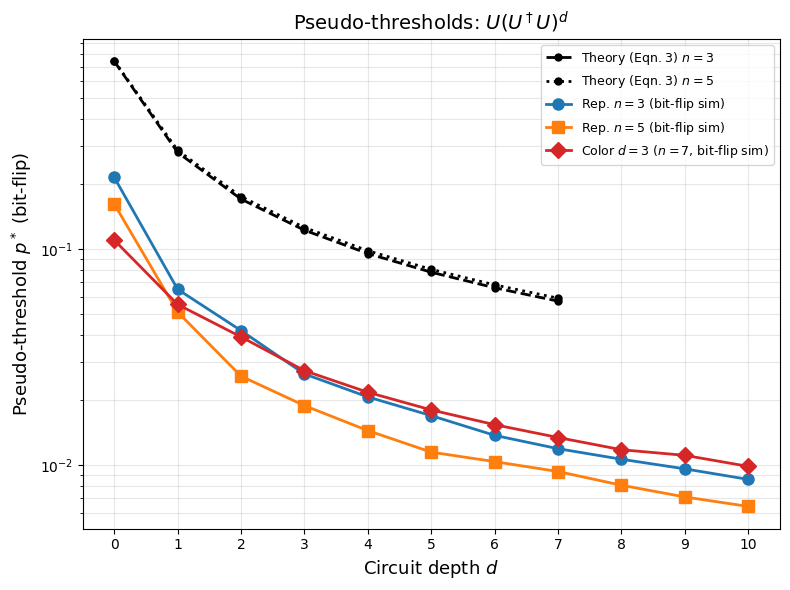


Summary (monotonicity-filtered):

Rep n=3:
  d=0: theory=  0.7418, sim=  0.2148
  d=1: theory=  0.2805, sim=  0.0651
  d=2: theory=  0.1705, sim=  0.0419
  d=3: theory=  0.1223, sim=  0.0264
  d=4: theory=  0.0953, sim=  0.0206
  d=5: theory=  0.0781, sim=  0.0169
  d=6: theory=  0.0661, sim=  0.0137
  d=7: theory=  0.0574, sim=  0.0119
  d=8: theory=     N/A, sim=  0.0106
  d=9: theory=     N/A, sim=  0.0096
  d=10: theory=     N/A, sim=  0.0086

Rep n=5:
  d=0: theory=  0.7458, sim=  0.1617
  d=1: theory=  0.2866, sim=  0.0511
  d=2: theory=  0.1750, sim=  0.0258
  d=3: theory=  0.1259, sim=  0.0188
  d=4: theory=  0.0982, sim=  0.0144
  d=5: theory=  0.0805, sim=  0.0114
  d=6: theory=  0.0683, sim=  0.0103
  d=7: theory=  0.0592, sim=  0.0093
  d=8: theory=     N/A, sim=  0.0080
  d=9: theory=     N/A, sim=  0.0071
  d=10: theory=     N/A, sim=  0.0064

Color d=3 (n=7):
  d=0: sim=  0.1100
  d=1: sim=  0.0554
  d=2: sim=  0.0392
  d=3: sim=  0.0273
  d=4: sim=  0.0217
  d=5: sim= 

In [18]:
# ============================================================
# Simulate pseudo-threshold vs circuit depth d for U(U†U)^d
# ============================================================
nshots_target = 200_000
depths = list(range(11))  # 0 to 10
# Fine resolution at low p (where high-depth crossings occur), coarser at high p
p_scan = np.sort(np.unique(np.concatenate([
    np.arange(0.002, 0.03, 0.002),
    np.arange(0.03, 0.30, 0.02),
])))
target_rep_ns = [3, 5]
target_cc_ds = [3]


def find_crossing(p_arr, phys_vals, enc_vals):
    """Find pseudo-threshold by linear interpolation of crossing point."""
    for i in range(len(p_arr) - 1):
        e1 = enc_vals.get(p_arr[i])
        e2 = enc_vals.get(p_arr[i + 1])
        p1 = phys_vals.get(p_arr[i])
        p2 = phys_vals.get(p_arr[i + 1])
        if e1 is not None and e2 is not None and p1 is not None and p2 is not None:
            d1 = e1 - p1
            d2 = e2 - p2
            if d1 > 0 and d2 <= 0:
                return float(p_arr[i] + (p_arr[i + 1] - p_arr[i]) * d1 / (d1 - d2))
    return None


# Cache physical results per depth (shared across rep codes)
phys_cache = {}
for d in depths:
    phys_cache[d] = {}
    for p in p_scan:
        c_phys = build_physical_bell_depth_bf(p, d)
        s_phys = c_phys.compile_sampler().sample(nshots_target)
        phys_cache[d][p] = eval_physical(s_phys)
    print(f"  Physical depth d={d} done")

# Repetition code
target_thresholds_raw = {}
for n in target_rep_ns:
    target_thresholds_raw[n] = {}
    for d in depths:
        enc_vals = {}
        for p in p_scan:
            c_enc = build_repetition_bell_depth_bf(n, p, d)
            s_enc = c_enc.compile_sampler().sample(nshots_target)
            enc_vals[p] = eval_repetition(s_enc, n)
        crossing = find_crossing(p_scan, phys_cache[d], enc_vals)
        target_thresholds_raw[n][d] = crossing
        status = f"p*={crossing:.4f}" if crossing else "no crossing"
        print(f"  Rep n={n}, depth d={d}: {status}")

# Color code
cc_target_thresholds_raw = {}
for d_code in target_cc_ds:
    cc_target_thresholds_raw[d_code] = {}
    for d in depths:
        enc_vals = {}
        for p in p_scan:
            c_enc, n_q, stabs = build_color_code_bell_depth_bf(d_code, p, d)
            s_enc = c_enc.compile_sampler().sample(nshots_target)
            enc_vals[p] = eval_color_code(s_enc, n_q, stabs)
        crossing = find_crossing(p_scan, phys_cache[d], enc_vals)
        cc_target_thresholds_raw[d_code][d] = crossing
        status = f"p*={crossing:.4f}" if crossing else "no crossing"
        print(f"  Color d={d_code}, depth d={d}: {status}")

# Enforce monotonicity (p* must decrease with depth; spurious upticks are noise)
target_thresholds = {n: enforce_monotonic(target_thresholds_raw[n], depths) for n in target_rep_ns}
cc_target_thresholds = {d: enforce_monotonic(cc_target_thresholds_raw[d], depths) for d in target_cc_ds}

# Theoretical curves (rep code only)
theory_target = {}
for n in target_rep_ns:
    theory_target[n] = {d: theoretical_threshold_depth(n, d) for d in depths}

# Plot: pseudo-threshold p* vs circuit depth d (log scale)
fig, ax = plt.subplots(figsize=(8, 6))

# Theory
for n_val in target_rep_ns:
    theory = theory_target[n_val]
    ds = [d for d in depths if theory[d] is not None]
    ps = [theory[d] for d in ds]
    ls = '--' if n_val == 3 else ':'
    ax.plot(ds, ps, f'k{ls}', linewidth=2, marker='.', markersize=10,
            label=f'Theory (Eqn. 3) $n={n_val}$')

# Rep code simulation
sim_colors = {3: 'tab:blue', 5: 'tab:orange'}
sim_markers = {3: 'o', 5: 's'}
for n_val in target_rep_ns:
    thresholds = target_thresholds[n_val]
    ds = [d for d in depths if thresholds[d] is not None]
    ps = [thresholds[d] for d in ds]
    ax.plot(ds, ps, f'{sim_markers[n_val]}-', color=sim_colors[n_val], linewidth=2,
            markersize=8, label=f'Rep. $n={n_val}$ (bit-flip sim)')

# Color code simulation
for d_code in target_cc_ds:
    n_q = len(get_stabilizer_generators(d_code)[0])
    thresholds = cc_target_thresholds[d_code]
    ds = [d for d in depths if thresholds[d] is not None]
    ps = [thresholds[d] for d in ds]
    ax.plot(ds, ps, 'D-', color='tab:red', linewidth=2, markersize=8,
            label=f'Color $d={d_code}$ ($n={n_q}$, bit-flip sim)')

ax.set_xlabel("Circuit depth $d$", fontsize=13)
ax.set_ylabel("Pseudo-threshold $p^*$ (bit-flip)", fontsize=13)
ax.set_title(r"Pseudo-thresholds: $U(U^\dagger U)^d$", fontsize=14)
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
ax.set_xticks(depths)

plt.tight_layout()
plt.savefig("paper/pseudothreshold_vs_distance.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nSummary (monotonicity-filtered):")
for n in target_rep_ns:
    print(f"\nRep n={n}:")
    for d in depths:
        t = theory_target[n][d]
        s = target_thresholds[n][d]
        r = target_thresholds_raw[n][d]
        filt = " (filtered)" if r is not None and s is None else ""
        print(f"  d={d}: theory={f'{t:.4f}' if t else 'N/A':>8s}, sim={f'{s:.4f}' if s else 'N/A':>8s}{filt}")
for d_code in target_cc_ds:
    n_q = len(get_stabilizer_generators(d_code)[0])
    print(f"\nColor d={d_code} (n={n_q}):")
    for d in depths:
        s = cc_target_thresholds[d_code][d]
        print(f"  d={d}: sim={f'{s:.4f}' if s else 'N/A':>8s}")

## Idle experiment: $U = I$

The $n=5$ repetition code has a lower pseudo-threshold than $n=3$ in the $U(U^\dagger U)^d$ protocol, likely due to error propagation through the non-transversal logical $H$. To test this, we repeat the pseudo-threshold analysis with $U = I$ (identity): prepare the encoded Bell state, then idle for the same number of noise layers as the corresponding $U(U^\dagger U)^d$ circuit. If $n=5$ beats $n=3$ in the idle case, the gate error propagation hypothesis is confirmed.

  Physical idle depth d=0 done


  Physical idle depth d=1 done


  Physical idle depth d=2 done


  Physical idle depth d=3 done


  Physical idle depth d=4 done


...

  Idle n=5, depth d=6: p*=0.0097


  Idle n=5, depth d=7: p*=0.0080


  Idle n=5, depth d=8: p*=0.0069


  Idle n=5, depth d=9: p*=0.0063


  Idle n=5, depth d=10: p*=0.0061


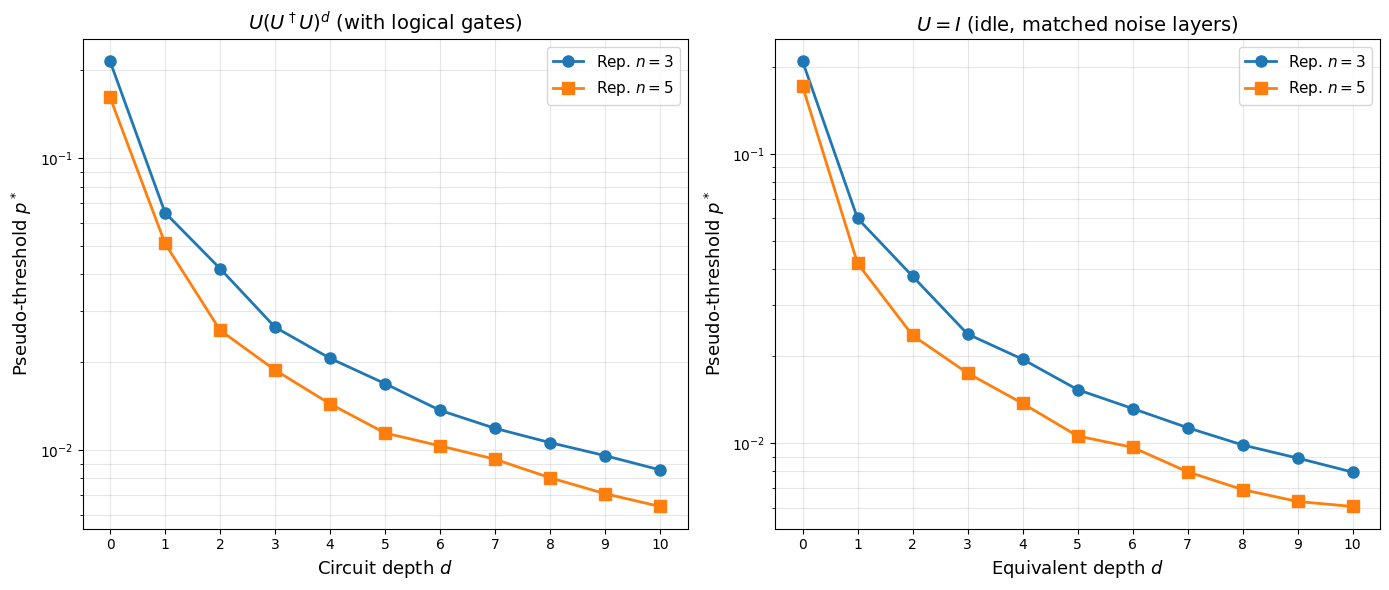


Idle experiment summary:

Rep n=3:
  d=0: gates=  0.2148, idle=  0.2093
  d=1: gates=  0.0651, idle=  0.0600
  d=2: gates=  0.0419, idle=  0.0378
  d=3: gates=  0.0264, idle=  0.0239
  d=4: gates=  0.0206, idle=  0.0195
  d=5: gates=  0.0169, idle=  0.0153
  d=6: gates=  0.0137, idle=  0.0132
  d=7: gates=  0.0119, idle=  0.0113
  d=8: gates=  0.0106, idle=  0.0099
  d=9: gates=  0.0096, idle=  0.0089
  d=10: gates=  0.0086, idle=  0.0080

Rep n=5:
  d=0: gates=  0.1617, idle=  0.1716
  d=1: gates=  0.0511, idle=  0.0419
  d=2: gates=  0.0258, idle=  0.0236
  d=3: gates=  0.0188, idle=  0.0175
  d=4: gates=  0.0144, idle=  0.0138
  d=5: gates=  0.0114, idle=  0.0106
  d=6: gates=  0.0103, idle=  0.0097
  d=7: gates=  0.0093, idle=  0.0080
  d=8: gates=  0.0080, idle=  0.0069
  d=9: gates=  0.0071, idle=  0.0063
  d=10: gates=  0.0064, idle=  0.0061


In [19]:
# ============================================================
# Idle experiment: U = I (no logical gates after Bell prep)
# Noise layers per depth matched to U(U†U)^d for fair comparison.
# ============================================================

# Cache physical idle results
phys_idle_cache = {}
for d in depths:
    phys_idle_cache[d] = {}
    for p in p_scan:
        c_phys = build_physical_idle_depth_bf(p, d)
        s_phys = c_phys.compile_sampler().sample(nshots_target)
        phys_idle_cache[d][p] = eval_physical(s_phys)
    print(f"  Physical idle depth d={d} done")

# Repetition code idle
idle_thresholds_raw = {}
for n in target_rep_ns:
    idle_thresholds_raw[n] = {}
    for d in depths:
        enc_vals = {}
        for p in p_scan:
            c_enc = build_repetition_idle_depth_bf(n, p, d)
            s_enc = c_enc.compile_sampler().sample(nshots_target)
            enc_vals[p] = eval_repetition(s_enc, n)
        crossing = find_crossing(p_scan, phys_idle_cache[d], enc_vals)
        idle_thresholds_raw[n][d] = crossing
        status = f"p*={crossing:.4f}" if crossing else "no crossing"
        print(f"  Idle n={n}, depth d={d}: {status}")

# Apply monotonicity filter
idle_thresholds = {n: enforce_monotonic(idle_thresholds_raw[n], depths) for n in target_rep_ns}

# Plot: side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: U(U†U)^d (with logical gates)
for n_val in target_rep_ns:
    thresholds = target_thresholds[n_val]
    ds = [d for d in depths if thresholds[d] is not None]
    ps = [thresholds[d] for d in ds]
    ax1.plot(ds, ps, f'{sim_markers[n_val]}-', color=sim_colors[n_val], linewidth=2,
             markersize=8, label=f'Rep. $n={n_val}$')
ax1.set_xlabel("Circuit depth $d$", fontsize=13)
ax1.set_ylabel("Pseudo-threshold $p^*$", fontsize=13)
ax1.set_title(r"$U(U^\dagger U)^d$ (with logical gates)", fontsize=14)
ax1.set_yscale('log')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, which='both')
ax1.set_xticks(depths)

# Right: Idle (U = I, no logical gates)
for n_val in target_rep_ns:
    thresholds = idle_thresholds[n_val]
    ds = [d for d in depths if thresholds[d] is not None]
    ps = [thresholds[d] for d in ds]
    ax2.plot(ds, ps, f'{sim_markers[n_val]}-', color=sim_colors[n_val], linewidth=2,
             markersize=8, label=f'Rep. $n={n_val}$')
ax2.set_xlabel("Equivalent depth $d$", fontsize=13)
ax2.set_ylabel("Pseudo-threshold $p^*$", fontsize=13)
ax2.set_title(r"$U = I$ (idle, matched noise layers)", fontsize=14)
ax2.set_yscale('log')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, which='both')
ax2.set_xticks(depths)

plt.tight_layout()
plt.savefig("paper/idle_vs_gates.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nIdle experiment summary:")
for n in target_rep_ns:
    print(f"\nRep n={n}:")
    for d in depths:
        g = target_thresholds[n][d]
        i = idle_thresholds[n][d]
        print(f"  d={d}: gates={f'{g:.4f}' if g else 'N/A':>8s}, idle={f'{i:.4f}' if i else 'N/A':>8s}")